# PROJECT 0
by Szymon Waliczek
 - Impact of spatial quantization and transverse confinement on 2DEG electron transport in **InAs**.
 - Plus closed system analysis.

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [ ]:
import kwant
import numpy as np
import scipy.sparse.linalg as sla
from matplotlib import pyplot as plt
from scipy.constants import physical_constants

In [ ]:
# Physical constants
h_bar = physical_constants['Planck constant over 2 pi'][0]
m_el = physical_constants['electron mass'][0]
eV = physical_constants['electron volt'][0]
m_eff = 0.023 * m_el
a = 5e-9
# hopping in eV
t = (h_bar**2 / (2 * m_eff * a**2)) / eV
W, L = 20, 30
freedom_deg = 1;

In [ ]:
# System
def make_system(W, L, a, t, deg):
    lat = kwant.lattice.square(a, norbs=deg)

    sys = kwant.Builder()
    sys[(lat(i, j) for i in range(W) for j in range(L))] = 4 * t
    sys[lat.neighbors()] = -t
    
    return sys, lat
#-------------------------------------------------------------------------
# Plot
def plot_system(sys):
    kwant.plot(sys, fig_size=(3, 3.5), show=False)
    plt.title("Lattice InAs (a = 5nm)") 
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.ticklabel_format(axis='both', style='sci', scilimits=(-9, -9), useMathText=True)
    plt.show()
#-------------------------------------------------------------------------
# Lead
def make_lead(sys, lat, a, t, W):
    sym_lead = kwant.TranslationalSymmetry((0, -a))
    lead = kwant.Builder(sym_lead)
    lead[(lat(i, 0) for i in range(W))] = 4 * t
    lead[lat.neighbors()] = -t

    sys.attach_lead(lead)
    sys.attach_lead(lead.reversed())

    return lead

In [ ]:
sys, lat = make_system(W, L, a, t, freedom_deg)
plot_system(sys)

In [ ]:
lead = make_lead(sys, lat, a, t, W).finalized()
plot_system(sys)
fsys = sys.finalized()

Energy relation with momentum in x_axis:

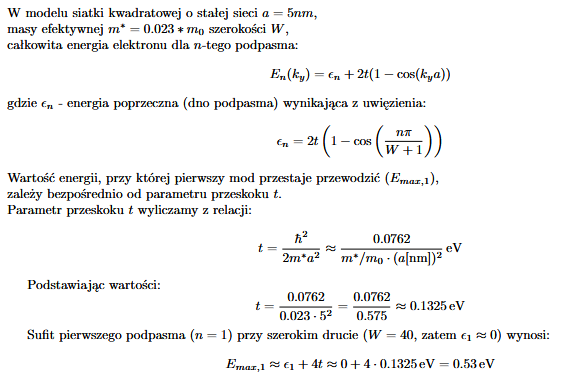

In [ ]:
# Relation of dispersion - bottom lead
kwant.plotter.bands(lead, fig_size=(5, 3), show=False)
plt.title("E(k_y) bottom lead")
plt.xlabel("k_y [1/a]")
plt.ylabel("[eV]")
plt.ylim(0, 0.2)
plt.show()

**Nie ma sensu patrzeć na wyższe energie bo zachodzi tam na brzegach błąd przybliżenia numerycznego, parabole powinny być w nieskończoność jadna na drugiej a nie się wypłaszczać**

In [ ]:
# Conductance
def plot_conductance(sys, Eb, Ef, n):
    energies = np.linspace(Eb, Ef, n)
    transmissions = []    
    for E in energies:
        smatrix = kwant.smatrix(sys, E)
        transmissions.append(smatrix.transmission(1, 0))
    plt.figure(figsize=(5, 3))
    plt.plot(energies, transmissions, lw=2)
    plt.title("Conductance") 
    plt.xlabel("E [eV]")
    plt.ylabel("G [e^2/h]")
    plt.grid()
    plt.show()

plot_conductance(sys=fsys, Eb=0, Ef=0.2, n=100)

**Conductance:**

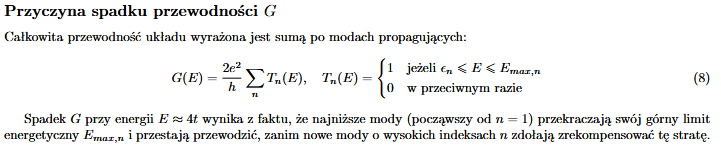

In [ ]:
Evals = [0.1, 0.2, 0.05]

In [ ]:
def plot_prob_density_open(sys, E):
    n = len(E)
    plt.figure(figsize=(7, 3.5))
    for i, en in enumerate(E):
        wf = kwant.wave_function(sys, energy=en)(0)
        if len(wf) > 0:
            plt.subplot(1, n, i + 1)
            d_map = sum(kwant.operator.Density(sys)(p) for p in wf)
            kwant.plotter.map(sys, d_map, ax=plt.gca(), show=False, cmap='viridis')
            plt.title(f"$|\Psi|^2$, E = {E} eV")
            plt.xlabel("x [m]"); 
            plt.ylabel("y [m]")
        else:
            print(f"No modes E = {en} eV.")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_prob_density_open(sys=fsys, E=Evals)

In [ ]:
def plot_prob_density_closed(sys, k):
    ham_mat = sys.hamiltonian_submatrix(sparse=True)
    evals, evecs = sla.eigsh(ham_mat.tocsc(), k=k, sigma=0)
    plt.figure(figsize=(9, 3.5))
    for i in range(k):
        density = np.abs(evecs[:, i])**2
        plt.subplot(1, k, i + 1)       
        kwant.plotter.map(sys, density, ax=plt.gca(), show=False)
        plt.title(f"E = {evals[i]:.4f} eV")
        plt.xlabel("x [m]"); 
        plt.ylabel("y [m]")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_prob_density_closed(sys=fsys, k=5)

In [ ]:
def plot_current_density(sys, E):
    n = len(E)
    plt.figure(figsize=(7, 4))
    for i, en in enumerate(E):
        wf = kwant.wave_function(sys, energy=en)(0)
        if len(wf) > 0:
            plt.subplot(1, n, i + 1)
            j = sum(kwant.operator.Current(sys)(p) for p in wf)
            kwant.plotter.current(sys, j, ax=plt.gca(), show=False, cmap='magma')            
            plt.title(f"j ( E = {en} eV)")
            plt.xlabel("x [m]"); 
            plt.ylabel("y [m]")
        else:
            print(f"No modes E = {en} eV.")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_current_density(sys=fsys, E=Evals)

In [ ]:
def plot_current_closed1(sys, E):
    ham_mat = sys.hamiltonian_submatrix(sparse=True)
    I = kwant.operator.Current(sys)
    n = len(E)   
    plt.figure(figsize=(7, 4))
    for i, en in enumerate(E):
        evals, evecs = sla.eigsh(ham_mat.tocsc(), k=1, sigma=en)
        E_found = evals[0]
        psi = evecs[:, 0]
        current = I(psi)    
        plt.subplot(1, n, i + 1)
        kwant.plotter.current(sys, current, ax=plt.gca(), show=False, cmap='magma')
        plt.title(f"E={E_found:.4f} eV")
        plt.xlabel("x [m]"); 
        plt.ylabel("y [m]")    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_current_closed1(sys=fsys, E=Evals)

In [ ]:
def plot_current_closed2(sys, k):
    ham_mat = sys.hamiltonian_submatrix(sparse=True)
    evals, evecs = sla.eigsh(ham_mat.tocsc(), k=k, sigma=0)
    J = kwant.operator.Current(sys)  
    plt.figure(figsize=(k * 4, 4.5))
    for i in range(k):
        current = J(evecs[:, i])
        plt.subplot(1, k, i + 1)
        kwant.plotter.current(sys, current, ax=plt.gca(), show=False, cmap='magma')        
        plt.title(f"E = {evals[i]:.4f} eV")
        plt.xlabel("x [m]"); 
        plt.ylabel("y [m]")    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_current_closed2(sys=fsys, k=5)